In [4]:
import pandas as pd


df = pd.read_csv('final_df.csv')

In [5]:
insulin_threshold = df.loc[df["split"] == "train", "import_insulin, Insulin [Units/volume] in Serum o"].quantile(0.90)

print(insulin_threshold)

1.9970000000000006


In [6]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, average_precision_score
from xgboost import XGBClassifier

def clean_col(c):
    return re.sub(r'[\[\]<>]', '', c)

race_cols = [c for c in df.columns if c.startswith('race_')]
df['race'] = df[race_cols].idxmax(axis=1).str.replace('race_', '', regex=False)

sex_cols = [c for c in df.columns if c.startswith('sex_')]
df['sex'] = df[sex_cols].idxmax(axis=1).str.replace('sex_', '', regex=False)

target_col = 'import_insulin, Insulin [Units/volume] in Serum o'

# --- binary label: top 10% of insulin, threshold from TRAIN split only ---
insulin_threshold = df.loc[df['split'] == 'train', target_col].quantile(0.90)
label_col = 'insulin_high'
df[label_col] = (df[target_col] >= insulin_threshold).astype(int)

print('Insulin threshold (90th pct, train only):', insulin_threshold)
print(df.loc[df['split'] == 'train', label_col].value_counts())

exclude = {
    'participant_id', 'study_group', 'split',
    target_col,
    label_col,
    'import_glucose, Glucose [Mass/volume] in Serum or',
    'max_glucose',
    'min_glucose',
    'mean_glucose',
    'std_glucose'
    'tar',
    'tir',
    'tbr'
}
feature_cols = [
    c for c in df.columns
    if c not in exclude
    and not c.startswith('race_')
    and not c.startswith('sex_')
]

print('Features:', feature_cols)

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
}

divider = '=' * 50
results = {}
prediction_rows = []

for group in df['study_group'].dropna().unique():
    print('')
    print(divider)
    print('Study Group:', group)
    print(divider)

    group_df = df[df['study_group'] == group].copy()
    group_df = group_df.replace([np.inf, -np.inf], np.nan)
    group_df = group_df.dropna(subset=feature_cols + [label_col])

    if len(group_df) < 20:
        print('Skipping - only', len(group_df), 'rows after dropping NAs (too few to model)')
        continue

    X = pd.get_dummies(group_df[feature_cols], columns=['sex', 'race'], drop_first=True)
    y = group_df[label_col]

    X_train = X[group_df['split'] == 'train']
    X_test  = X[group_df['split'] == 'test']
    y_train = y[group_df['split'] == 'train']
    y_test  = y[group_df['split'] == 'test']

    if y_train.nunique() < 2 or y_test.nunique() < 2:
        print('Skipping - only one class present in train or test split')
        continue

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ----- Logistic Regression -----
    logreg = LogisticRegression(max_iter=5000)
    logreg.fit(X_train_scaled, y_train)
    logreg_preds = logreg.predict(X_test_scaled)
    logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]

    logreg_acc = accuracy_score(y_test, logreg_preds)
    logreg_auprc = average_precision_score(y_test, logreg_proba)

    print('')
    print('Logistic Regression')
    print('  Accuracy:', logreg_acc)
    print('  AUPRC:', logreg_auprc)

    # ----- Logistic Regression w/ ElasticNet penalty (CV) -----
    logreg_enet = LogisticRegressionCV(
        cv=5,
        penalty='elasticnet',
        solver='saga',
        l1_ratios=[0.1, 0.5, 0.7, 0.9, 1.0],
        max_iter=5000,
        random_state=42
    )
    logreg_enet.fit(X_train_scaled, y_train)
    enet_preds = logreg_enet.predict(X_test_scaled)
    enet_proba = logreg_enet.predict_proba(X_test_scaled)[:, 1]

    enet_acc = accuracy_score(y_test, enet_preds)
    enet_auprc = average_precision_score(y_test, enet_proba)

    print('')
    print('Logistic ElasticNet (C=', logreg_enet.C_[0], ', l1_ratio=', logreg_enet.l1_ratio_[0], ')')
    print('  Accuracy:', enet_acc)
    print('  AUPRC:', enet_auprc)

    selected_features = X.columns[logreg_enet.coef_[0] != 0].tolist()
    print('  Selected features (non-zero coef):', selected_features)

    # ----- XGBoost with GridSearchCV -----
    X_train_xgb = X_train.copy()
    X_test_xgb = X_test.copy()
    X_train_xgb.columns = [clean_col(c) for c in X_train_xgb.columns]
    X_test_xgb.columns = [clean_col(c) for c in X_test_xgb.columns]

    xgb_grid = GridSearchCV(
        estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
        param_grid=xgb_param_grid,
        cv=5,
        scoring='average_precision',
        n_jobs=1,
        verbose=0
    )
    xgb_grid.fit(X_train_xgb, y_train)
    xgb_preds = xgb_grid.predict(X_test_xgb)
    xgb_proba = xgb_grid.predict_proba(X_test_xgb)[:, 1]

    test_ids = group_df.loc[group_df['split'] == 'test', 'participant_id'].values
    prediction_rows.append(pd.DataFrame({
        'participant_id': test_ids,
        'study_group': group,
        'actual_insulin_high': y_test.values,
        'pred_insulin_high_logreg': logreg_preds,
        'pred_insulin_high_enet': enet_preds,
        'pred_insulin_high_xgb': xgb_preds,
        'proba_insulin_high_logreg': logreg_proba,
        'proba_insulin_high_enet': enet_proba,
        'proba_insulin_high_xgb': xgb_proba,
    }))

    xgb_acc = accuracy_score(y_test, xgb_preds)
    xgb_auprc = average_precision_score(y_test, xgb_proba)

    print('')
    print('XGBoost (GridSearchCV)')
    print('  Best params:', xgb_grid.best_params_)
    print('  Accuracy:', xgb_acc)
    print('  AUPRC:', xgb_auprc)

    results[group] = {
        'n': len(group_df),
        'logreg_acc': logreg_acc,
        'logreg_auprc': logreg_auprc,
        'enet_acc': enet_acc,
        'enet_auprc': enet_auprc,
        'xgboost_acc': xgb_acc,
        'xgboost_auprc': xgb_auprc,
        'xgboost_best_params': xgb_grid.best_params_
    }

print('')
print(divider)
print('Summary')
print(divider)
summary_df_2 = pd.DataFrame(results).T
print(summary_df_2)

prediction_2 = pd.concat(prediction_rows, ignore_index=True)
print('')
print('Prediction dataframe:')
print(prediction_2.head())

Insulin threshold (90th pct, train only): 1.9970000000000006
insulin_high
0    1596
1     178
Name: count, dtype: int64
Features: ['age', 'pulse_vsorres, Heart Rate (bpm)', 'bmi_vsorres, BMI', 'import_hba1c, Hemoglobin A1c/Hemoglobin.total in ', 'import_albumin, Albumin [Mass/volume] in Serum or', 'import_a_g_ratio, Albumin/Globulin ratio', 'import_globulin_total, Globulin [Mass/volume] in ', 'import_protein_total, Protein [Mass/volume] in Se', 'import_c_peptide, C peptide [Mass/volume] in Seru', 'import_calcium, Calcium [Mass/volume] in Serum or', 'import_chloride, Chloride [Moles/volume] in Serum', 'import_sodium, Sodium [Moles/volume] in Serum or ', 'import_potassium, Potassium [Moles/volume] in Ser', 'import_carbon_dioxide_total, Carbon dioxide, tota', 'import_creatinine, Creatinine [Mass/volume] in Se', 'import_bun, Urea nitrogen [Mass/volume] in Serum ', 'import_buncreatinineratio, BUN/Creatinine ratio', 'import_urine_albumin, Albumin [Mass/volume] in Ur', 'import_urine_creatinin

/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/sklearn/linear_model/_logistic


Logistic ElasticNet (C= 0.3593813663804626 , l1_ratio= 1.0 )
  Accuracy: 0.9181818181818182
  AUPRC: 0.7082936507936508
  Selected features (non-zero coef): ['bmi_vsorres, BMI', 'import_globulin_total, Globulin [Mass/volume] in ', 'import_c_peptide, C peptide [Mass/volume] in Seru', 'import_creatinine, Creatinine [Mass/volume] in Se', 'import_bun, Urea nitrogen [Mass/volume] in Serum ', 'import_alkaline_phosphatase, Alkaline phosphatase', 'import_alt_got, Alanine aminotransferase [Enzymat', 'import_ast_got, Aspartate aminotransferase [Enzym', 'import_troponin_t, Troponin T.cardiac [Mass/volum', 'import_total_cholesterol, Cholesterol [Mass/volum', 'import_hdl_cholesterol, Cholesterol in HDL [Mass/', 'import_ldl_cholesterol, Cholesterol in LDL [Mass/', 'import_triglycerides, Triglyceride [Mass/volume] ', 'num_days', 'avg_sleep_minutes', 'avg_sleep_hours', 'tar', 'race_White or Caucasian']

XGBoost (GridSearchCV)
  Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth'

/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/sklearn/linear_model/_logistic


Logistic ElasticNet (C= 0.3593813663804626 , l1_ratio= 0.5 )
  Accuracy: 0.9539473684210527
  AUPRC: 0.8131657251338102
  Selected features (non-zero coef): ['age', 'pulse_vsorres, Heart Rate (bpm)', 'bmi_vsorres, BMI', 'import_hba1c, Hemoglobin A1c/Hemoglobin.total in ', 'import_albumin, Albumin [Mass/volume] in Serum or', 'import_protein_total, Protein [Mass/volume] in Se', 'import_c_peptide, C peptide [Mass/volume] in Seru', 'import_calcium, Calcium [Mass/volume] in Serum or', 'import_chloride, Chloride [Moles/volume] in Serum', 'import_potassium, Potassium [Moles/volume] in Ser', 'import_creatinine, Creatinine [Mass/volume] in Se', 'import_bun, Urea nitrogen [Mass/volume] in Serum ', 'import_urine_albumin, Albumin [Mass/volume] in Ur', 'import_urine_creatinine, Creatinine [Mass/volume]', 'import_alt_got, Alanine aminotransferase [Enzymat', 'import_ast_got, Aspartate aminotransferase [Enzym', 'import_bilirubin_total, Bilirubin.total [Mass/vol', 'import_crp_hs, C reactive protein [M

/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/sklearn/linear_model/_logistic


Logistic ElasticNet (C= 0.3593813663804626 , l1_ratio= 0.9 )
  Accuracy: 0.9398496240601504
  AUPRC: 0.8957999136878447
  Selected features (non-zero coef): ['age', 'bmi_vsorres, BMI', 'import_a_g_ratio, Albumin/Globulin ratio', 'import_globulin_total, Globulin [Mass/volume] in ', 'import_c_peptide, C peptide [Mass/volume] in Seru', 'import_sodium, Sodium [Moles/volume] in Serum or ', 'import_carbon_dioxide_total, Carbon dioxide, tota', 'import_creatinine, Creatinine [Mass/volume] in Se', 'import_bun, Urea nitrogen [Mass/volume] in Serum ', 'import_urine_creatinine, Creatinine [Mass/volume]', 'import_bilirubin_total, Bilirubin.total [Mass/vol', 'import_crp_hs, C reactive protein [Mass/volume] i', 'import_nt_probnp, Natriuretic peptide.B prohormon', 'import_troponin_t, Troponin T.cardiac [Mass/volum', 'import_triglycerides, Triglyceride [Mass/volume] ', 'avg_sleep_minutes', 'avg_sleep_hours', 'cv_glucose', 'sex_Male', 'race_Native Hawaiian or other Pacific Islander', 'race_Other race, 

/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
/home/chc1596/.conda/envs/tabfm/lib/python3.11/site-packages/sklearn/linear_model/_logistic


Logistic ElasticNet (C= 0.3593813663804626 , l1_ratio= 0.1 )
  Accuracy: 0.8541666666666666
  AUPRC: 0.5212861212861213
  Selected features (non-zero coef): ['age', 'pulse_vsorres, Heart Rate (bpm)', 'bmi_vsorres, BMI', 'import_albumin, Albumin [Mass/volume] in Serum or', 'import_a_g_ratio, Albumin/Globulin ratio', 'import_protein_total, Protein [Mass/volume] in Se', 'import_c_peptide, C peptide [Mass/volume] in Seru', 'import_calcium, Calcium [Mass/volume] in Serum or', 'import_chloride, Chloride [Moles/volume] in Serum', 'import_sodium, Sodium [Moles/volume] in Serum or ', 'import_potassium, Potassium [Moles/volume] in Ser', 'import_carbon_dioxide_total, Carbon dioxide, tota', 'import_creatinine, Creatinine [Mass/volume] in Se', 'import_bun, Urea nitrogen [Mass/volume] in Serum ', 'import_buncreatinineratio, BUN/Creatinine ratio', 'import_urine_albumin, Albumin [Mass/volume] in Ur', 'import_alkaline_phosphatase, Alkaline phosphatase', 'import_alt_got, Alanine aminotransferase [Enzym

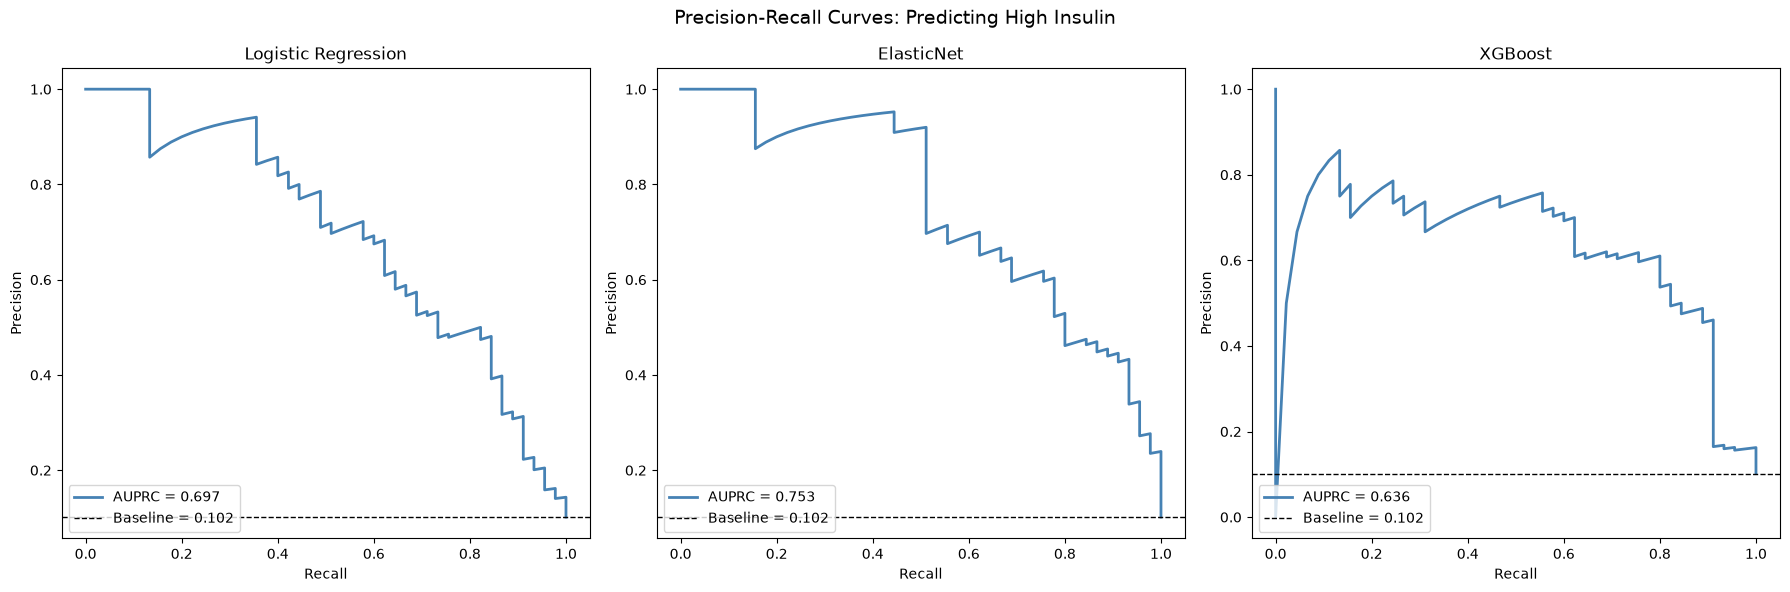

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
models = ['logreg', 'enet', 'xgb']
names = ['Logistic Regression', 'ElasticNet', 'XGBoost']

for ax, model, name in zip(axes, models, names):
    actual = prediction_2['actual_insulin_high']
    proba = prediction_2[f'proba_insulin_high_{model}']

    precision, recall, _ = precision_recall_curve(actual, proba)
    auprc = average_precision_score(actual, proba)
    baseline = actual.mean()

    ax.plot(recall, precision, color='steelblue', linewidth=2, label=f'AUPRC = {auprc:.3f}')
    ax.axhline(baseline, color='k', linestyle='--', linewidth=1, label=f'Baseline = {baseline:.3f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(name)
    ax.legend(loc='lower left')

fig.suptitle('Precision-Recall Curves: Predicting High Insulin', fontsize=14)
plt.tight_layout()
plt.show()


In [8]:
summary_df_2

,n,logreg_acc,logreg_auprc,enet_acc,enet_auprc,xgboost_acc,xgboost_auprc,xgboost_best_params
pre_diabetes_lifestyle_controlled,549,0.954545,0.698303,0.918182,0.708294,0.909091,0.713004,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
healthy,759,0.947368,0.69427,0.953947,0.813166,0.934211,0.744219,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
oral_medication_and_or_non_insulin_injectable_medication_controlled,663,0.93985,0.865454,0.93985,0.8958,0.924812,0.687435,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
insulin_dependent,246,0.791667,0.41274,0.854167,0.521286,0.895833,0.374258,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
